In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from dphase.state import PhaseSpaceSpecies, PhaseSpaceState
from dphase.grid import PhaseSpaceGrid
from dphase.cosmology import relic_abundance,  compute_yields_from_snaps

from dphase.kernels.annihilation_sm import build_xxff_kernels
from dphase.kernels.annihilation_hidden import build_annihilation_loss_kernels, build_annihilation_gain_caches
from dphase.kernels.elastic_hidden import build_xAxA_gain_caches
from dphase.kernels.elastic_sm import build_xfxf_kernels

from dphase.solver import solve_BE
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 15,
})


In [2]:
######################
### Set up the species and model parameters
######################

MCHI = 10.0
MA = 5.0
ALPHA = 1.0e-6
EPSILON= 1.0e-10

chi = PhaseSpaceSpecies(name="chi", mass_GeV=MCHI, dof=2.0)
A = PhaseSpaceSpecies(name="A", mass_GeV= MA, dof=3.0)

In [3]:
################################################
### Set up the momentum grid
################################################

x_span   = (0.05, 100) # x-evolution range

T_ref    = chi.mass_GeV / x_span[0]
T_final  = chi.mass_GeV / x_span[1]
T_span   = (T_ref, T_final)
p_tilde_min = 1e-2 * chi.mass_GeV
p_tilde_max = 50.0 * T_ref
grid = PhaseSpaceGrid(ptilde_min= p_tilde_min, ptilde_max=p_tilde_max, Np=120, T_ref=T_ref)

T_grid = np.geomspace(T_span[0], T_span[1], 150)


In [4]:
###########################
## Set things in the state
###########################

state = PhaseSpaceState(grid, [chi, A])
state.T_grid = np.asarray(T_grid, dtype=float)   # shape (NT,)

state.epsilon = EPSILON
state.alphaD = ALPHA

state.Nmu = 6

In [5]:
###########################
## Precompute the kernels for all the collision terms
###########################


kernels_xxff = build_xxff_kernels(
    T_span=T_grid,
    state=state,
    m_initial = chi.mass_GeV,
    m_mediator=A.mass_GeV
)

kernels_loss_xxAA  = build_annihilation_loss_kernels(T_span=T_grid, state=state,
                                    mchi = chi.mass_GeV, mA = A.mass_GeV,
                                    direction =  "xxAA" )
kernels_loss_AAxx  = build_annihilation_loss_kernels(T_span=T_grid, state=state,
                                    mchi = chi.mass_GeV, mA = A.mass_GeV,
                                    direction =  "AAxx" )

gain_caches_ann  = build_annihilation_gain_caches(T_grid, state)


gain_caches_dc = build_xAxA_gain_caches(T_grid, state, Nphi_cm = 6)

  xA-gain [1/150]: T=2.000e+02 GeV  N_events=1310761
  xA-gain [16/150]: T=9.305e+01 GeV  N_events=1211384
  xA-gain [31/150]: T=4.329e+01 GeV  N_events=1118450
  xA-gain [46/150]: T=2.014e+01 GeV  N_events=1034566
  xA-gain [61/150]: T=9.370e+00 GeV  N_events=963262
  xA-gain [76/150]: T=4.360e+00 GeV  N_events=905580
  xA-gain [91/150]: T=2.028e+00 GeV  N_events=861047
  xA-gain [106/150]: T=9.436e-01 GeV  N_events=829274
  xA-gain [121/150]: T=4.390e-01 GeV  N_events=808714
  xA-gain [136/150]: T=2.043e-01 GeV  N_events=797479


In [6]:
#######################
#### Elastic scattering
#######################

gamma_grid = build_xfxf_kernels(T_grid, state)
gamma_grid_chi =  np.array([g['chi'] for g in gamma_grid])
gamma_grid_A = np.array([g['A'] for g in gamma_grid])


In [7]:
#######################
#### Set all the kernels and caches in the state
#######################

state.K_grid_xxff = kernels_xxff

######### new kernels and gain caches
state.gain_caches_xxAA  = gain_caches_ann
state.K_grid_AAxx       = kernels_loss_AAxx
state.K_grid_xxAA       = kernels_loss_xxAA

state.T_grid = np.asarray(T_grid, dtype=float)

######### set the dc cache
state.gain_caches_xAxA = gain_caches_dc

######### set the elastic scattering kernels
state.gamma_grid_chi = gamma_grid_chi
state.gamma_grid_A = gamma_grid_A

In [8]:
#######################
#### Run the solver
#######################


# set the initial conditions (empty hidden sector)
p0 = grid.p_phys(T_ref, gstars_func= state.gstar_func)
state.set_initial_f("chi", np.zeros_like(p0))
state.set_initial_f("A", np.zeros_like(p0))



Gamma_H_max = 50
T_vals, snapshots = solve_BE(
    state, T_grid,
    Gamma_H_max = Gamma_H_max,
)

Step 0/149: T=190.053 GeV Γ_HS/H=0.0e+00 hs_scale=1.00e+00 Γ_sc/H=1.5e-22 η_sc=0.0e+00 sc_scale=1.00e+00 Γ_dc/H=0.0e+00 dc_scale=1.00e+00 |f|=5.43e-10
Step 10/149: T=114.112 GeV Γ_HS/H=2.1e-06 hs_scale=1.00e+00 Γ_sc/H=4.3e-22 η_sc=4.2e-16 sc_scale=1.00e+00 Γ_dc/H=3.0e-06 dc_scale=1.00e+00 |f|=1.04e-08
Step 20/149: T=68.515 GeV Γ_HS/H=1.6e-05 hs_scale=1.00e+00 Γ_sc/H=1.2e-21 η_sc=6.9e-16 sc_scale=1.00e+00 Γ_dc/H=1.2e-05 dc_scale=1.00e+00 |f|=3.76e-08
Step 30/149: T=41.138 GeV Γ_HS/H=9.2e-05 hs_scale=1.00e+00 Γ_sc/H=3.4e-21 η_sc=1.1e-15 sc_scale=1.00e+00 Γ_dc/H=5.3e-05 dc_scale=1.00e+00 |f|=1.12e-07
Step 40/149: T=24.700 GeV Γ_HS/H=4.6e-04 hs_scale=1.00e+00 Γ_sc/H=9.7e-21 η_sc=3.1e-15 sc_scale=1.00e+00 Γ_dc/H=2.9e-04 dc_scale=1.00e+00 |f|=3.12e-07
Step 50/149: T=14.830 GeV Γ_HS/H=1.7e-03 hs_scale=1.00e+00 Γ_sc/H=2.8e-20 η_sc=2.2e-15 sc_scale=1.00e+00 Γ_dc/H=1.3e-03 dc_scale=1.00e+00 |f|=8.17e-07
Step 60/149: T=8.904 GeV Γ_HS/H=3.5e-03 hs_scale=1.00e+00 Γ_sc/H=7.7e-20 η_sc=3.4e-15 sc_scal

/var/folders/gh/dkmyc07x05s0k1vgjj6s10hw0000gn/T/ipykernel_4368/2351857533.py:54: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0.0, 200)


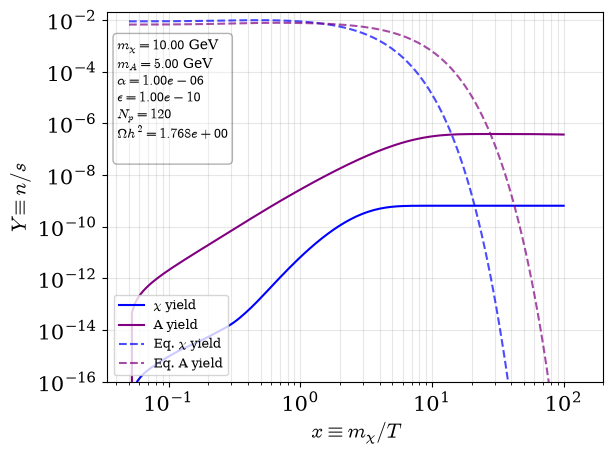

In [9]:
########################
### Plot yields vs x = m/T
########################

color_chi = "blue"
color_A = "purple"
m_scale = state.species["chi"].mass_GeV

x_vals = m_scale / np.asarray(T_vals)


Y_vals, Y_vals_A, Y_eq_vals, Y_eq_vals_A, nchi_vals, nA_vals = (
    compute_yields_from_snaps(T_vals, MCHI, MA, state, snapshots)
)

omegah2 = relic_abundance(Y_vals[-1], m_scale)

# --- plot Y vs x ---

plt.figure()

plt.loglog(x_vals, Y_vals, label=f"$\\chi$ yield", color=color_chi, linestyle="-")
plt.loglog(x_vals, Y_vals_A, label=f"A yield", color=color_A, linestyle="-")

### equilibrium
plt.loglog(x_vals, Y_eq_vals, linestyle="--", label=f"Eq. $\\chi$ yield", color=color_chi, alpha=0.7)
plt.loglog(x_vals, Y_eq_vals_A, linestyle="--", label=f"Eq. A yield", color=color_A, alpha=0.7)

plt.xlabel(r"$x \equiv m_\chi/T$")
plt.ylabel(r"$Y \equiv n/s$")
plt.grid(True, which="both", alpha=0.3)



param_text = (
    f"$m_\\chi={chi.mass_GeV:.2f}$ GeV\n"
    f"$m_A={A.mass_GeV:.2f}$ GeV\n"
    f"$\\alpha={ALPHA:.2e}$\n"
    f"$\\epsilon={EPSILON:.2e}$\n"
    f"$N_p={state.grid._Np}$\n"
    f"$\\Omega h^2 = {omegah2:.3e}$\n"
)

plt.text(
    0.02, 0.6, param_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.3),
)

################# now overlay Y_chi_imp and Y_A_imp from the previous run (with old kernels) for comparison
plt.xlim(0.0, 200)
plt.ylim(1e-16, 2e-2)
plt.legend(fontsize=9, loc = 'lower left')
plt.show()